      Number  Sequence Length  Halfway Point  Max Value in Sequence  \
0          1                1              1                      1   
1          2                2              1                      2   
2          3                8              8                     16   
3          4                3              2                      4   
4          5                6              4                     16   
...      ...              ...            ...                    ...   
9994    9995               66          15208                  44980   
9995    9996              180          83501                 250504   
9996    9997              180          83501                 250504   
9997    9998               92           2429                  33748   
9998    9999               92           2429                 101248   

      Mean Value in Sequence  Ratio of 3x+1 to x/2  
0                   1.000000              0.000000  
1                   1.500000             

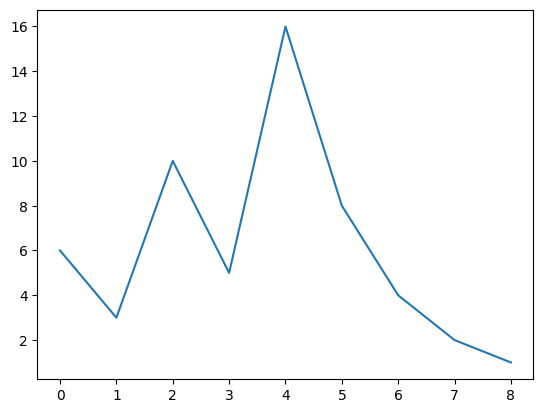

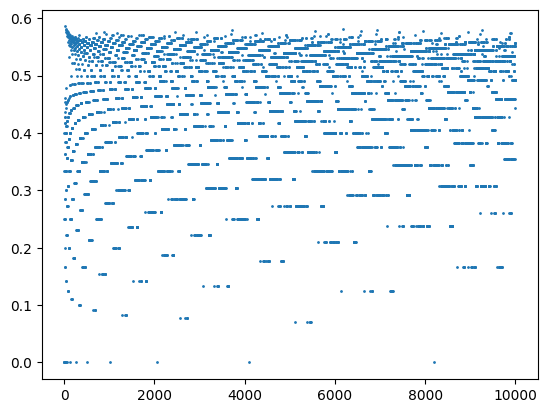

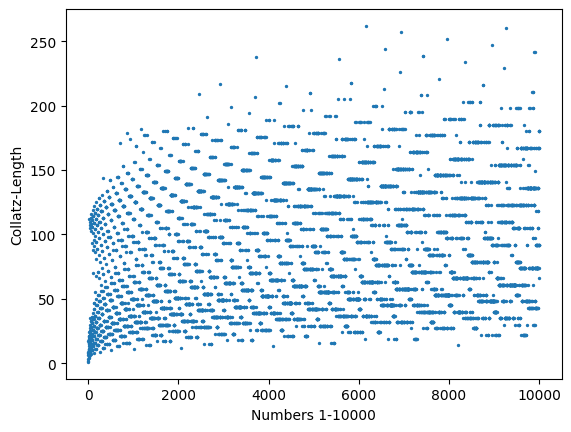

0.4546171957911184


'\navgs = []\nfor i in range(1, 10000):\n  avgs.append(average_ratio(i))\n\nsteps = range(len(avgs))\nplt.scatter(steps, avgs, s=1)\nplt.show()\n'

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#Returns a number after going through the collatz function
def collatz(x):
  if x % 2 == 0:
    return x/2
  if x % 2 == 1:
    return 3*x + 1

#Returns a list assigned to the entire collatz sequence of a number
def collatz_sequence(num):
  current = []
  while num != 1:
    current.append(int(num))
    num = collatz(num)
  current.append(1)
  return current

#Takes a number and returns the length of its collatz sequence
def collatz_length(num):
  return len(collatz_sequence(num))

#Takes a number and graphs its collatz sequence
def graph_collatz_sequence(num):
  seq = collatz_sequence(num)
  steps = range(len(seq))
  plt.plot(steps, seq)
  plt.show

#Takes a max value and returns a dictionary with each number up to the max value and its collatz length
def get_data(max):
  data  = {}
  for i in range(1, max):
    data[i] = collatz_length(i)
  return data

#Takes a maximum value and graphs the collatz lengths of each number up to the max value
def graph_length_data(max):
  data = get_data(max)
  x = list(data.keys())
  y= list(data.values())
  plt.xlabel("Numbers 1-" + str(max))
  plt.ylabel("Collatz-Length")
  plt.scatter(x, y, s=2)
  plt.show()

#Takes a max value and returns the number in that range with the longest collatz length
def longest_sequence(max):
  data = get_data(max)
  max_ind = 1
  for i in data:
    if data[i] > data[max_ind]:
      max_ind = i

  return max_ind

#Takes a number and returns the highest number reached in its collatz sequence
def max_val(num):
  max = 1
  for i in collatz_sequence(num):
    if i > max:
      max = i
  return max

#Takes a number and returns the mean value of its collatz sequence
def mean_val(num):
  mean = 0
  seq = collatz_sequence(num)
  for i in seq:
    mean += i
  mean = mean/len(seq)
  return mean

#Takes a number and returns a ratio of how many odd to even numbers it reaches in its collatz sequence
def collatz_ratio(num):
  even_count = 0
  odd_count = -1
  seq = collatz_sequence(num)
  for i in seq:
    if i%2 == 0:
      even_count +=1
    if i%2 == 1:
      odd_count +=1
  if even_count == 0:
    return 0
  return odd_count/even_count

#Takes a max value and graphs each number up to that value and its collatz ratio
def graph_ratio_data(max):
  ratios = []
  for i in range(1, max):
    ratios.append(collatz_ratio(i))
  steps = range(len(ratios))
  plt.scatter(steps, ratios, s=1)
  plt.show

#Takes max value and returns the average collatz ratio
def average_ratio(max):
  avg = 0
  for i in range(1, max):
    avg += collatz_ratio(i)

  avg = avg/max
  return avg

#Creates a panda for all numbers up to the max value
def create_panda(max):
  dataset = {
  'Number': [],
  'Sequence Length': [],
  'Halfway Point' : [],
  'Max Value in Sequence' : [],
  'Mean Value in Sequence' : [],
  'Ratio of 3x+1 to x/2' : []
  }
  for i in range(1, max):
    dataset['Number'].append(i)
    dataset['Sequence Length'].append(collatz_length(i))
    dataset['Halfway Point'].append(collatz_sequence(i)[int(collatz_length(i)/2)])
    dataset['Max Value in Sequence'].append(max_val(i))
    dataset['Mean Value in Sequence'].append(mean_val(i))
    dataset['Ratio of 3x+1 to x/2'].append(collatz_ratio(i))
  return pd.DataFrame(dataset)

graph_collatz_sequence(6)

print(create_panda(10000))

plt.figure()
graph_ratio_data(10000)
plt.figure()
graph_length_data(10000)

print(average_ratio(10000))
"""
avgs = []
for i in range(1, 10000):
  avgs.append(average_ratio(i))

steps = range(len(avgs))
plt.scatter(steps, avgs, s=1)
plt.show()
"""


Here, I convert the panda into a csv file:

In [ ]:
panda = create_panda(10000)
panda.to_csv('panda.csv')

# Reflection:
There has to be a solution to the collatz conjecture!
There is obviously a pattern when you plot the collatz lengths on a scatter plot, but it seems hard to predict.
I also wondered if there would be a pattern if you plotted the ratio of odd to even numbers encountered in the sequence of each number. Turns out, there was a pattern. Also, you would think that the ratio of odd to even numbers encountered would be around 50:50, but most ratios turned out to be somehwere around 0.56. However, if you calculate the total average of collatz ratios up to 10000, it lies somewhere around 0.45.
I then went a step further and plotted how the average collatz ratio changed as each number increased, and you get a graph that actually makes sense and could mean something.
It takes a very long time to load as it has a time complexity of O(n^3log(n)), but once it loads, you can see a distinct function (see picture below). I don't know the exact equation for this function, but the value approaches 0.5, which means on average you have twice as many even numbers as odd numbers. This makes sense, because when you think about it:
3x+1--> EVEN
x/2 --> (EVEN, ODD)
So, basically one odd over two evens equals 0.5.
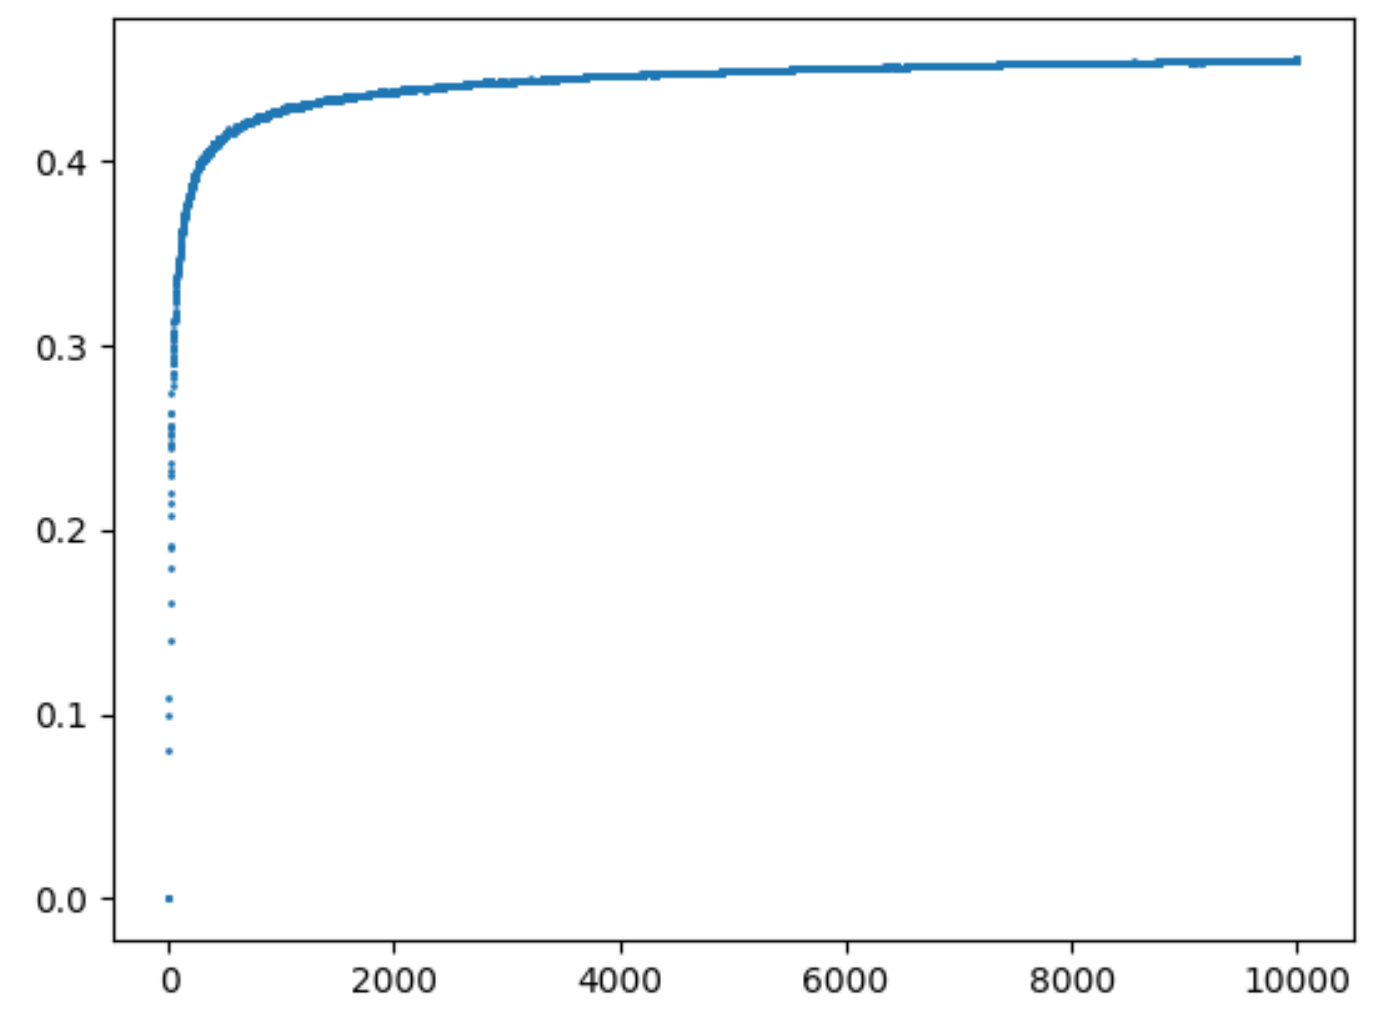


I asked ChatGPT to optimize my code. You can see that it used memoization, which honestly makes sense, and I should have done, because the collatz function doesn't change so you can store the values of each number already so you don't have to rerun each number through the Collatz function each time you do a different operation.
It also makes the average ratio function run a lot faster.

      Number  Sequence Length  Halfway Point  Max Value in Sequence  \
0          1                1              1                      1   
1          2                2              1                      2   
2          3                8              8                     16   
3          4                3              2                      4   
4          5                6              4                     16   
...      ...              ...            ...                    ...   
9994    9995               66          15208                  44980   
9995    9996              180          83501                 250504   
9996    9997              180          83501                 250504   
9997    9998               92           2429                  33748   
9998    9999               92           2429                 101248   

      Mean Value in Sequence  Ratio of 3x+1 to x/2  
0                   1.000000              0.000000  
1                   1.500000             

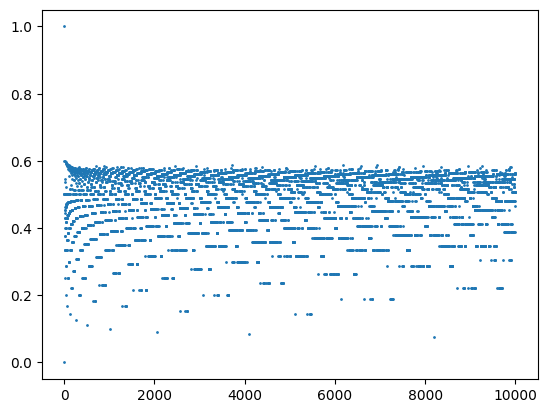

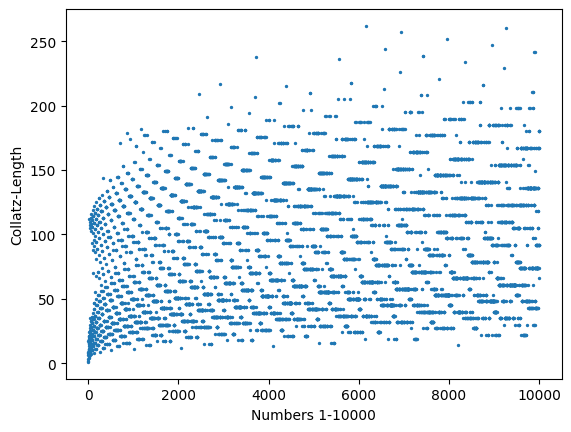

0.47871700533766814


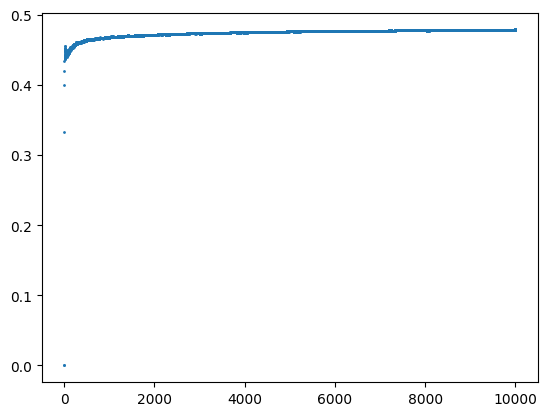

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from functools import lru_cache

# Using memoization to cache results of collatz sequence calculations
@lru_cache(maxsize=None)
def collatz(x):
    if x % 2 == 0:
        return x // 2
    return 3 * x + 1

@lru_cache(maxsize=None)
def collatz_sequence(num):
    sequence = []
    while num != 1:
        sequence.append(num)
        num = collatz(num)
    sequence.append(1)
    return sequence

@lru_cache(maxsize=None)
def collatz_length(num):
    return len(collatz_sequence(num))

@lru_cache(maxsize=None)
def max_val(num):
    return max(collatz_sequence(num))

@lru_cache(maxsize=None)
def mean_val(num):
    seq = collatz_sequence(num)
    return sum(seq) / len(seq)

@lru_cache(maxsize=None)
def collatz_ratio(num):
    seq = collatz_sequence(num)
    even_count = sum(1 for i in seq if i % 2 == 0)
    odd_count = len(seq) - even_count
    return odd_count / even_count if even_count > 0 else 0

def graph_collatz_sequence(num):
    seq = collatz_sequence(num)
    steps = range(len(seq))
    plt.plot(steps, seq)
    plt.show()

def get_data(max):
    data = {i: collatz_length(i) for i in range(1, max)}
    return data

def graph_length_data(max):
    data = get_data(max)
    x = list(data.keys())
    y = list(data.values())
    plt.xlabel(f"Numbers 1-{max}")
    plt.ylabel("Collatz-Length")
    plt.scatter(x, y, s=2)
    plt.show()

def longest_sequence(max):
    return max(range(1, max), key=collatz_length)

def graph_ratio_data(max):
    ratios = [collatz_ratio(i) for i in range(1, max)]
    steps = range(len(ratios))
    plt.scatter(steps, ratios, s=1)
    plt.show()

def average_ratio(max):
    total_ratio = sum(collatz_ratio(i) for i in range(1, max))
    return total_ratio / max

def create_panda(max):
    dataset = {
        'Number': range(1, max),
        'Sequence Length': [collatz_length(i) for i in range(1, max)],
        'Halfway Point': [collatz_sequence(i)[collatz_length(i) // 2] for i in range(1, max)],
        'Max Value in Sequence': [max_val(i) for i in range(1, max)],
        'Mean Value in Sequence': [mean_val(i) for i in range(1, max)],
        'Ratio of 3x+1 to x/2': [collatz_ratio(i) for i in range(1, max)]
    }
    return pd.DataFrame(dataset)

# Example usage:
max_value = 10000
print(create_panda(max_value))

graph_ratio_data(max_value)
plt.figure()
graph_length_data(max_value)

print(average_ratio(max_value))
avgs = [average_ratio(i) for i in range(1, max_value)]
steps = range(len(avgs))
plt.scatter(steps, avgs, s=1)
plt.show()
